# Reproduce the paper's figures — from the committed production artifacts

**Paper:** *Knowledge Distillation with PySR on the PRIYA suite* — a
**derivative-faithfulness diagnostic** of per-parameter 1D symbolic regression
(PySR) as a Fisher emulator for the Lyman-α P1D. It asks *where, why, and how
badly* a PySR equation that nails the P1D **value** can still get the **slope**
∂logP/∂θ wrong (the "Fisher's Mirage"), and what a **Sobolev** derivative-matching
loss does and does not fix.

## The reproduce model

> **The committed Pareto fronts + grad-faith sidecars ARE the artifact.**
> The one production run
> (`results/paper_production_20260630_perz_sobolev_z2.6-4.2/`, git-committed)
> emitted, next to every PySR Pareto CSV, a **grad-faith sidecar** that already
> carries the two emulator-grounded numbers each figure needs — `grad_err`
> (median_k |∂P_eq/∂θ ÷ ∂P_GP/∂θ − 1| at fid, the production gate metric) and
> `value_mse` (a common, cross-objective-comparable value loss). **Tier-1 figures
> replay those CSVs emulator-free** — no GP, no PySR, no Julia.

## The two tiers

| tier | needs | figures | this notebook |
|------|-------|---------|---------------|
| **Tier 1** | numpy / pandas / matplotlib / scipy only | `pareto_faithfulness`, `faithfulness_scorecard`, `ns_budget_panel`, `crossz_faithfulness`, `maxsize_sensitivity`, `seed_band` | **executes** them below |
| **Tier 2** | the GP emulator + the `.venv` (Julia/PySR **not** needed) | prediction figs (`pysr_pred_tau0_Ap`, `pysr_graphs_3.6_dtau0`, `2d-denorm-Sobol_dtau0-Ap`) + multi-D best/worst | **documents** the commands (not run here) |

See `REPRODUCE.md` for the clone-and-run guide and the full figure→command table.

## 0. Setup — locate the repo, the production run, and the light deps

Tier-1 is emulator-free: we only put `src/` on the path (for the three tiny
`priya_forecast` helper modules) and point at the committed production run. **No**
`lya_emulator_full`, GP basedir, or Julia/PySR env var is imported for Tier-1.

In [1]:
import os, sys, subprocess, json
from pathlib import Path

# Repo root = parent of this notebooks/ dir (fall back to cwd if __file__-less).
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
REPO = HERE if (HERE / "src").exists() else HERE.parent
assert (REPO / "src" / "priya_forecast").exists(), f"src not found under {REPO}"
os.chdir(REPO)                      # the regen scripts use relative results/ paths
SRC = str(REPO / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

PROD = Path("results/paper_production_20260630_perz_sobolev_z2.6-4.2")
assert (PROD / "RUN_MANIFEST.md").exists(), f"production run not found at {PROD}"

# All reproduced figures land here (git-ignored: results/_repro_scratch/).
REPRO = Path("results/_repro_scratch/reproduced_figures")
REPRO.mkdir(parents=True, exist_ok=True)

import matplotlib
matplotlib.use("Agg")              # headless; we display the saved PNGs inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from priya_forecast.parameters import PARAM_NAMES
from priya_forecast.grad_faith_io import read_grad_faith_sidecar, knee_row
from priya_forecast.pareto_diag import GATE_TOL

print("repo      :", REPO)
print("prod run  :", PROD)
print("params    :", list(PARAM_NAMES))
print("gate tol  :", GATE_TOL)
print("emulator  : NOT loaded for Tier-1 (no GPy / PySR / Julia)")

repo      : /home/mfho/lya1d_priya_forecast
prod run  : results/paper_production_20260630_perz_sobolev_z2.6-4.2
params    : ['dtau0', 'tau0', 'ns', 'Ap', 'herei', 'heref', 'alphaq', 'hub', 'omegamh2', 'hireionz', 'bhfeedback']
gate tol  : 0.25
emulator  : NOT loaded for Tier-1 (no GPy / PySR / Julia)


### The committed production layout (what Tier-1 reads)

The run stamped its recipe in `RUN_MANIFEST.md`: one PySR model per (param, z),
Sobolev λ=5 (log target) vs a plain-MSE **value** baseline, z ∈ {2.6, 3.6, 4.2},
maxsize=20; plus a 5-seed band and an ns budget control (maxsize=35), all at z=3.6.
The sidecars Tier-1 replays live at:

- `value/refit/z3.6/`   — value-loss fits (maxsize 20), all 11 params
- `sobolev/refit/z<z>/` — Sobolev fits, z = 2.6 / 3.6 / 4.2
- `seed_band/z3.6_seed0_budget/refit/z3.6/` — the ns budget-control (maxsize 35)
- `sens_maxsize{30,40}_{value,sobolev}/`, `budget35_{value,sobolev}/` — the sweep
- `seed_band/seed_band_summary.json` — aggregated 5-seed medians/ranges

In [2]:
# Subprocess helper: run a regen script with the SAME interpreter + PYTHONPATH=src.
# Keeps Tier-1 self-contained (no shell env assumptions) and emulator-free.
def run_script(args, label):
    env = dict(os.environ, PYTHONPATH="src")
    print(f"$ PYTHONPATH=src python {' '.join(str(a) for a in args)}")
    r = subprocess.run([sys.executable, *map(str, args)], env=env,
                       cwd=REPO, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print(r.stderr[-2000:])
        raise RuntimeError(f"{label} failed (exit {r.returncode})")
    tail = "\n".join(r.stdout.strip().splitlines()[-3:])
    print(tail if tail else "(ok)")
    return r

---
# Tier 1 — emulator-free figures

Everything below runs top-to-bottom with only numpy / pandas / matplotlib / scipy.
Each cell regenerates a figure into `results/_repro_scratch/reproduced_figures/`
and shows it inline.

## 1.1 The four diagnostic figures (`pareto_faithfulness`, `faithfulness_scorecard`, `ns_budget_panel`, `crossz_faithfulness`)

These are the paper's diagnostic-section figures. `scripts/make_diagnostic_figs.py`
reads the value / Sobolev / budget grad-faith sidecars and the cross-z Sobolev
sidecars — **no emulator**. This is the exact production invocation from the
script header (see also `RUN_MANIFEST.md` §"Next"):

- **`pareto_faithfulness`** — 11-panel grid, y = `value_mse`, colour = `grad_err`,
  gate rings + the ns-Mirage arrow.
- **`faithfulness_scorecard`** — per-parameter value-optimal `grad_err`, value ● vs
  Sobolev ■, gate dashed.
- **`ns_budget_panel`** — the ns budget control: a deeper (maxsize 35) value-loss
  search reaches low value error but stays seed-fragile at the gate; Sobolev clears
  it reliably.
- **`crossz_faithfulness`** — redshift robustness of the taxonomy at z = 2.6/3.6/4.2.

In [3]:
diag_out = REPRO / "diagnostic"
run_script([
    "scripts/make_diagnostic_figs.py",
    "--value-dir",   PROD / "value/refit/z3.6",
    "--sobolev-dir", PROD / "sobolev/refit/z3.6",
    "--budget-dir",  PROD / "seed_band/z3.6_seed0_budget/refit/z3.6",
    "--crossz-dirs",
        f"2.6={PROD}/sobolev/refit/z2.6",
        f"3.6={PROD}/sobolev/refit/z3.6",
        f"4.2={PROD}/sobolev/refit/z4.2",
    "--out-dir", diag_out,
], "make_diagnostic_figs")

$ PYTHONPATH=src python scripts/make_diagnostic_figs.py --value-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/value/refit/z3.6 --sobolev-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6 --budget-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/seed_band/z3.6_seed0_budget/refit/z3.6 --crossz-dirs 2.6=results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z2.6 3.6=results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6 4.2=results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z4.2 --out-dir results/_repro_scratch/reproduced_figures/diagnostic


wrote 4 figures (png+pdf) to results/_repro_scratch/reproduced_figures/diagnostic


CompletedProcess(args=['/home/mfho/lya1d_priya_forecast/.venv/bin/python', 'scripts/make_diagnostic_figs.py', '--value-dir', 'results/paper_production_20260630_perz_sobolev_z2.6-4.2/value/refit/z3.6', '--sobolev-dir', 'results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6', '--budget-dir', 'results/paper_production_20260630_perz_sobolev_z2.6-4.2/seed_band/z3.6_seed0_budget/refit/z3.6', '--crossz-dirs', '2.6=results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z2.6', '3.6=results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6', '4.2=results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z4.2', '--out-dir', 'results/_repro_scratch/reproduced_figures/diagnostic'], returncode=0, stdout='wrote 4 figures (png+pdf) to results/_repro_scratch/reproduced_figures/diagnostic\n', stderr='')

pareto_faithfulness


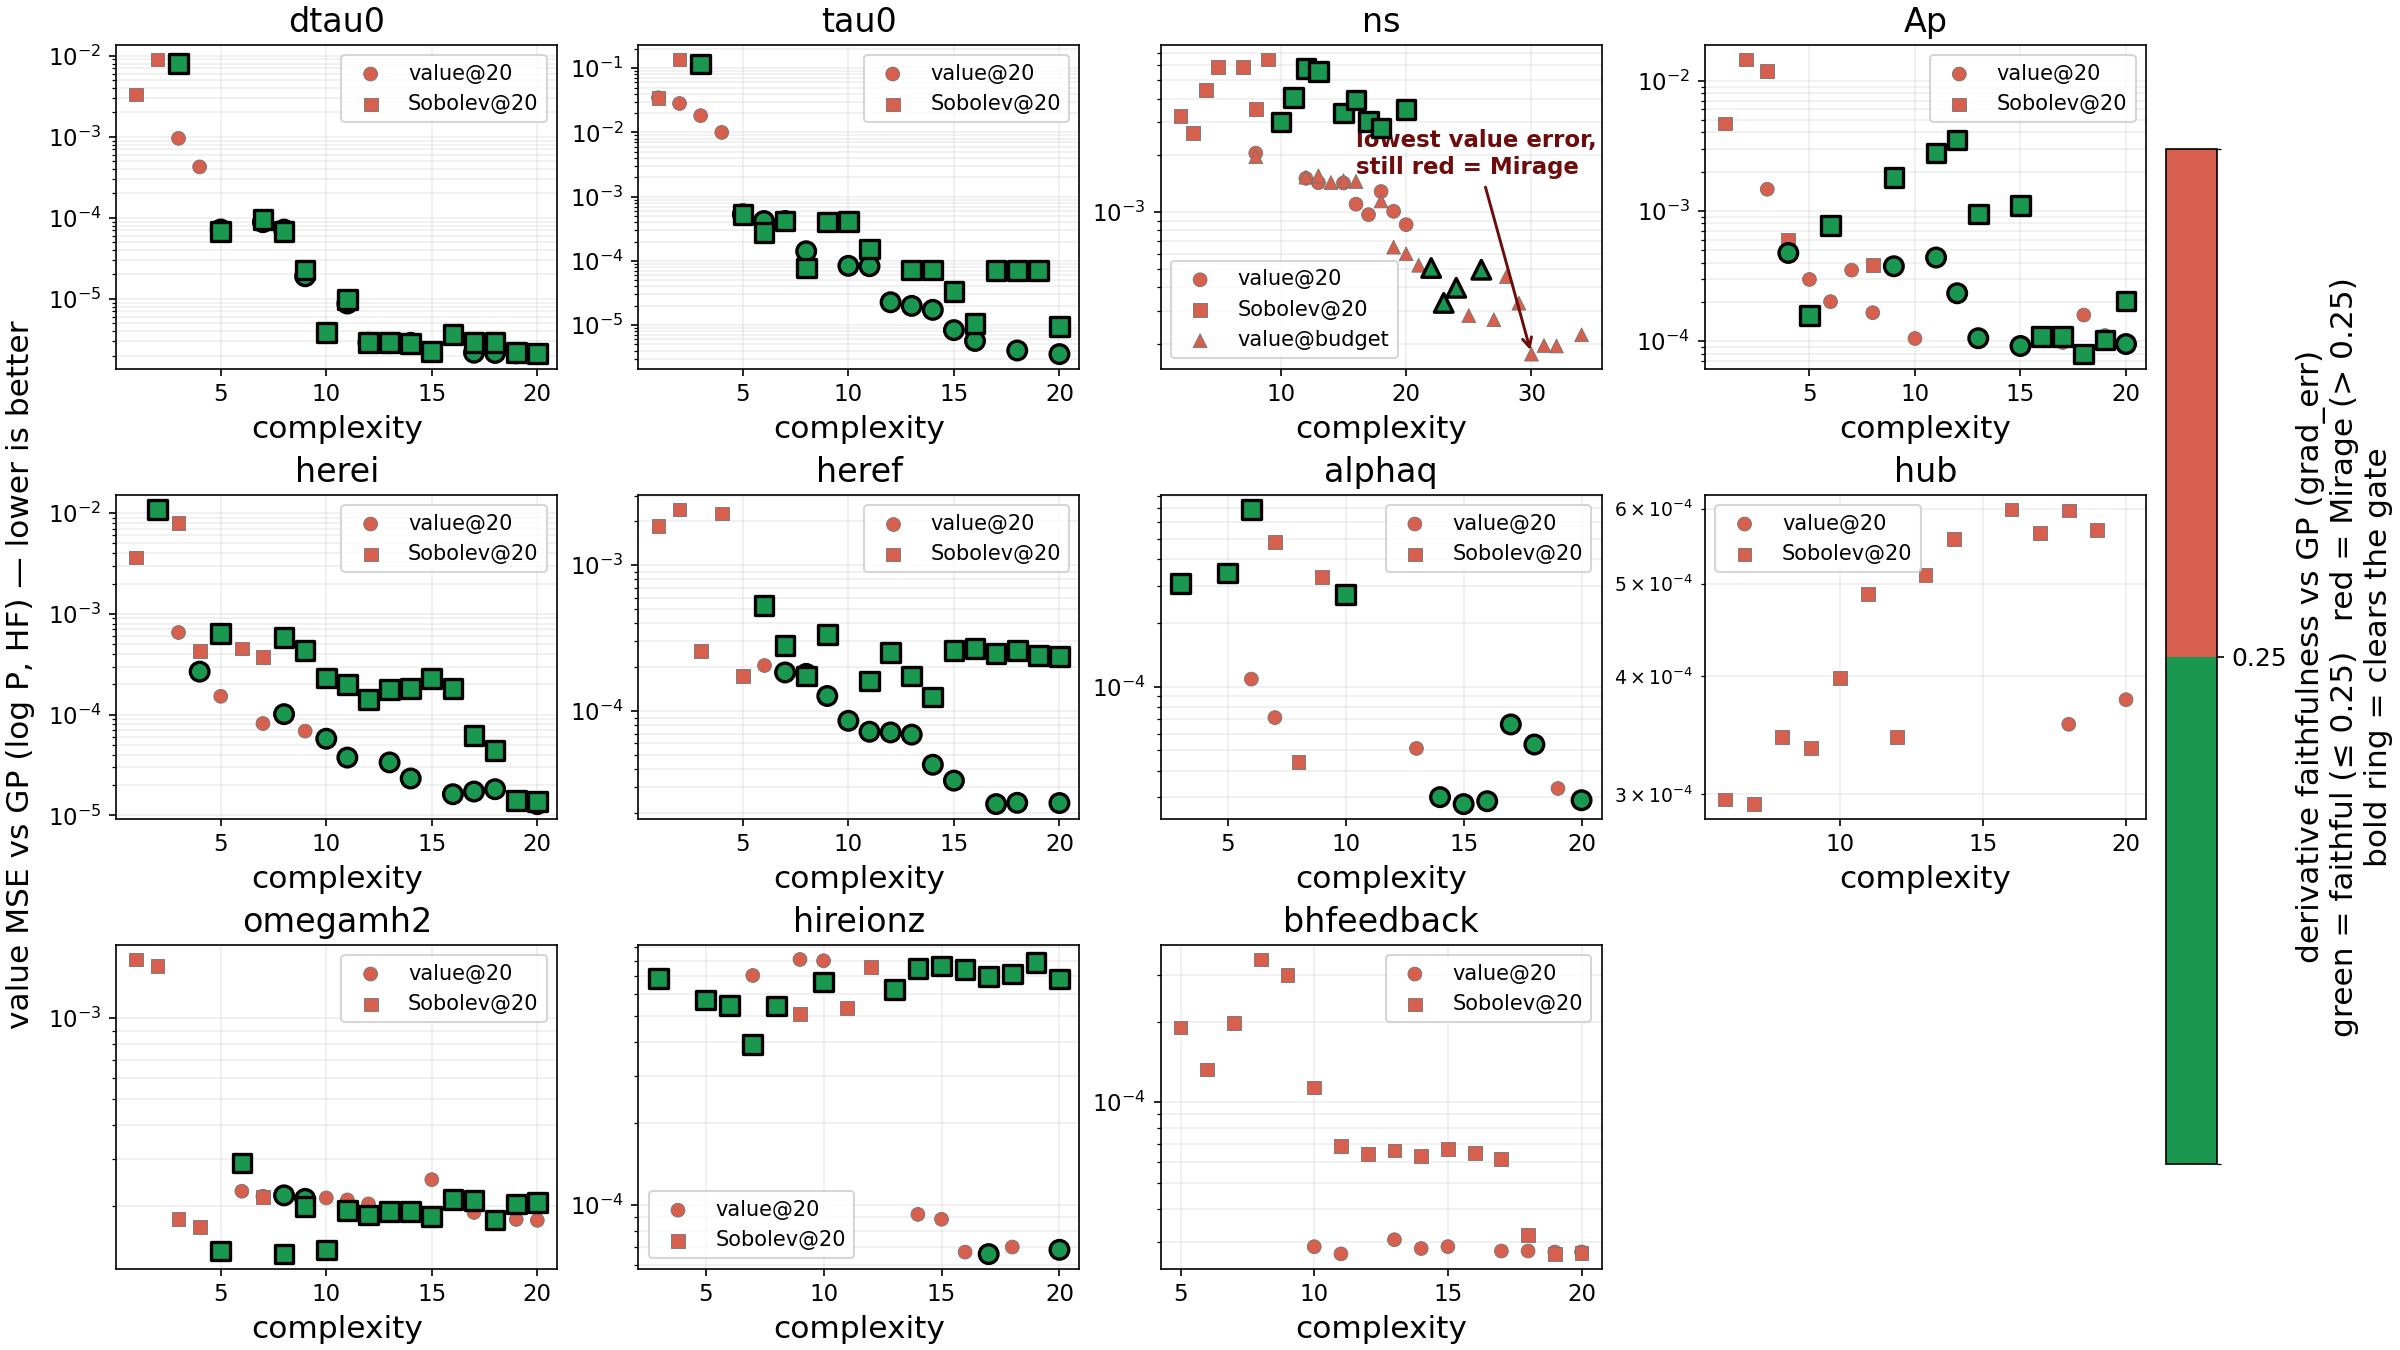

faithfulness_scorecard


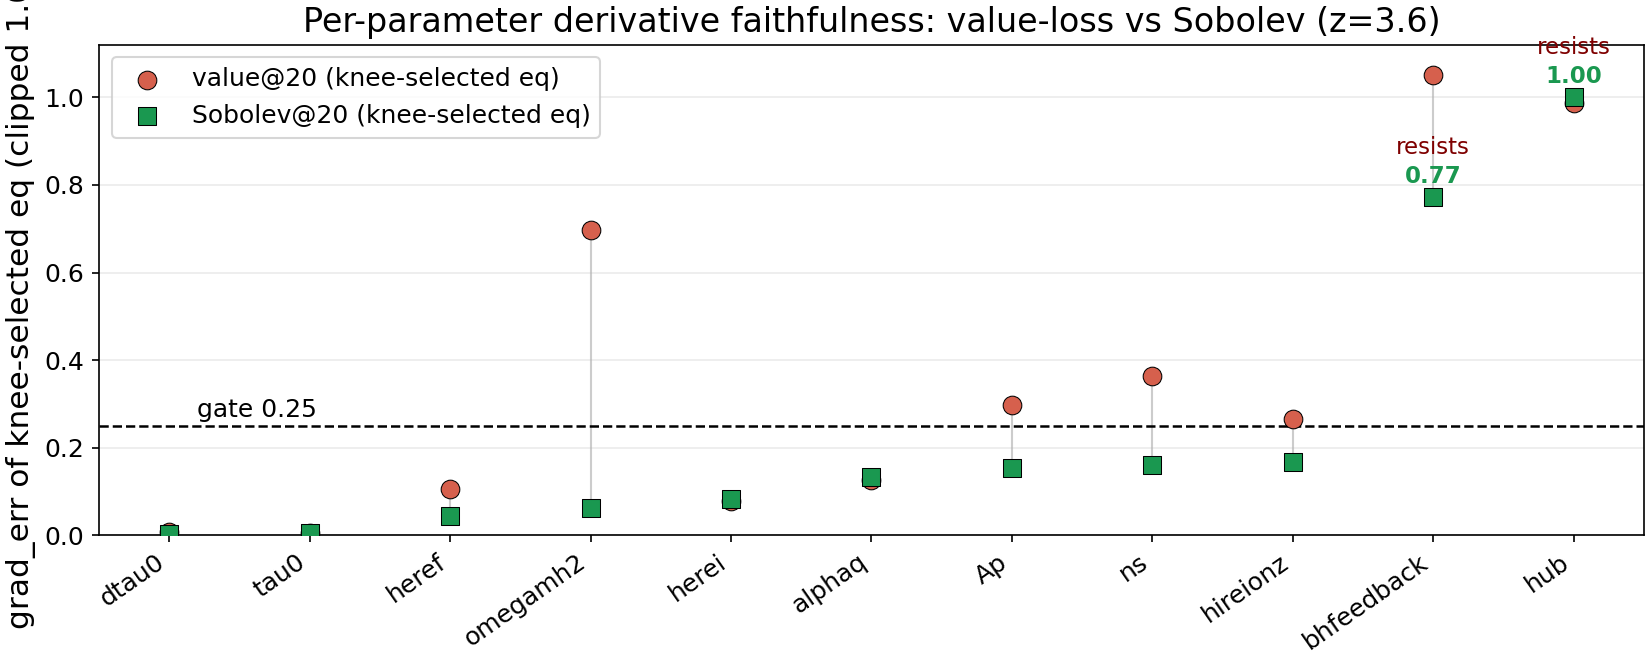

ns_budget_panel


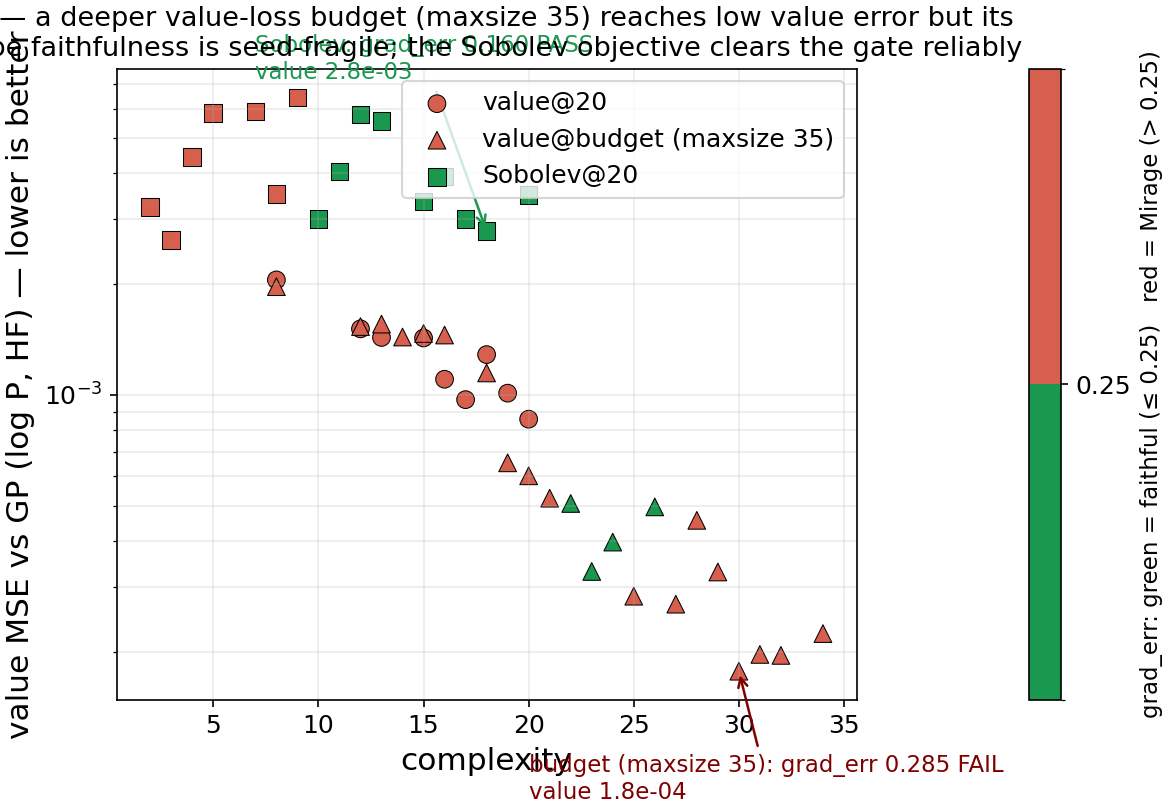

crossz_faithfulness


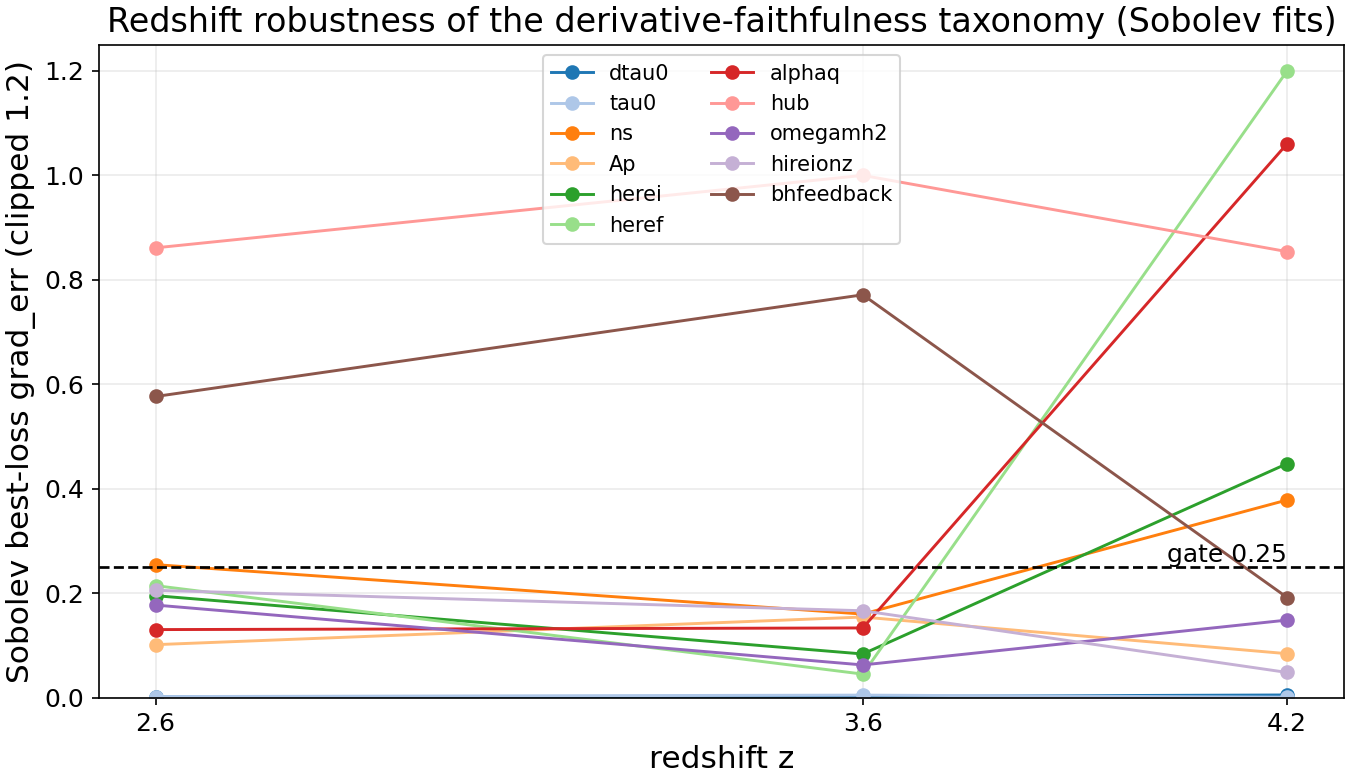

In [4]:
for name in ["pareto_faithfulness", "faithfulness_scorecard",
             "ns_budget_panel", "crossz_faithfulness"]:
    print(name)
    display(Image(filename=str(diag_out / f"{name}.png")))

## 1.2 `maxsize_sensitivity` — is the ns Mirage just search-starvation?

`scripts/regen_maxsize_sensitivity.py` reads the knee-selected `grad_err` from the
grad-faith sidecars at four complexity budgets (maxsize ∈ {20, 30, 35, 40}) for
both objectives — again **no emulator re-run**. The story it makes visible: under
the **value** objective the knee `grad_err` falls as the budget grows (the equation
needed a bigger budget), whereas **Sobolev** is already low at maxsize=20 and stays
flat — Sobolev is search-efficient; value-loss faithfulness is budget-sensitive.

$ PYTHONPATH=src python scripts/regen_maxsize_sensitivity.py --prod results/paper_production_20260630_perz_sobolev_z2.6-4.2 --z 3.6 --out-dir results/_repro_scratch/reproduced_figures/maxsize


       hub  sobolev | 1.000 0.996 0.996 1.059
bhfeedback    value | 1.418 0.797 0.948 1.275
bhfeedback  sobolev | 0.771 0.576 0.676 0.750


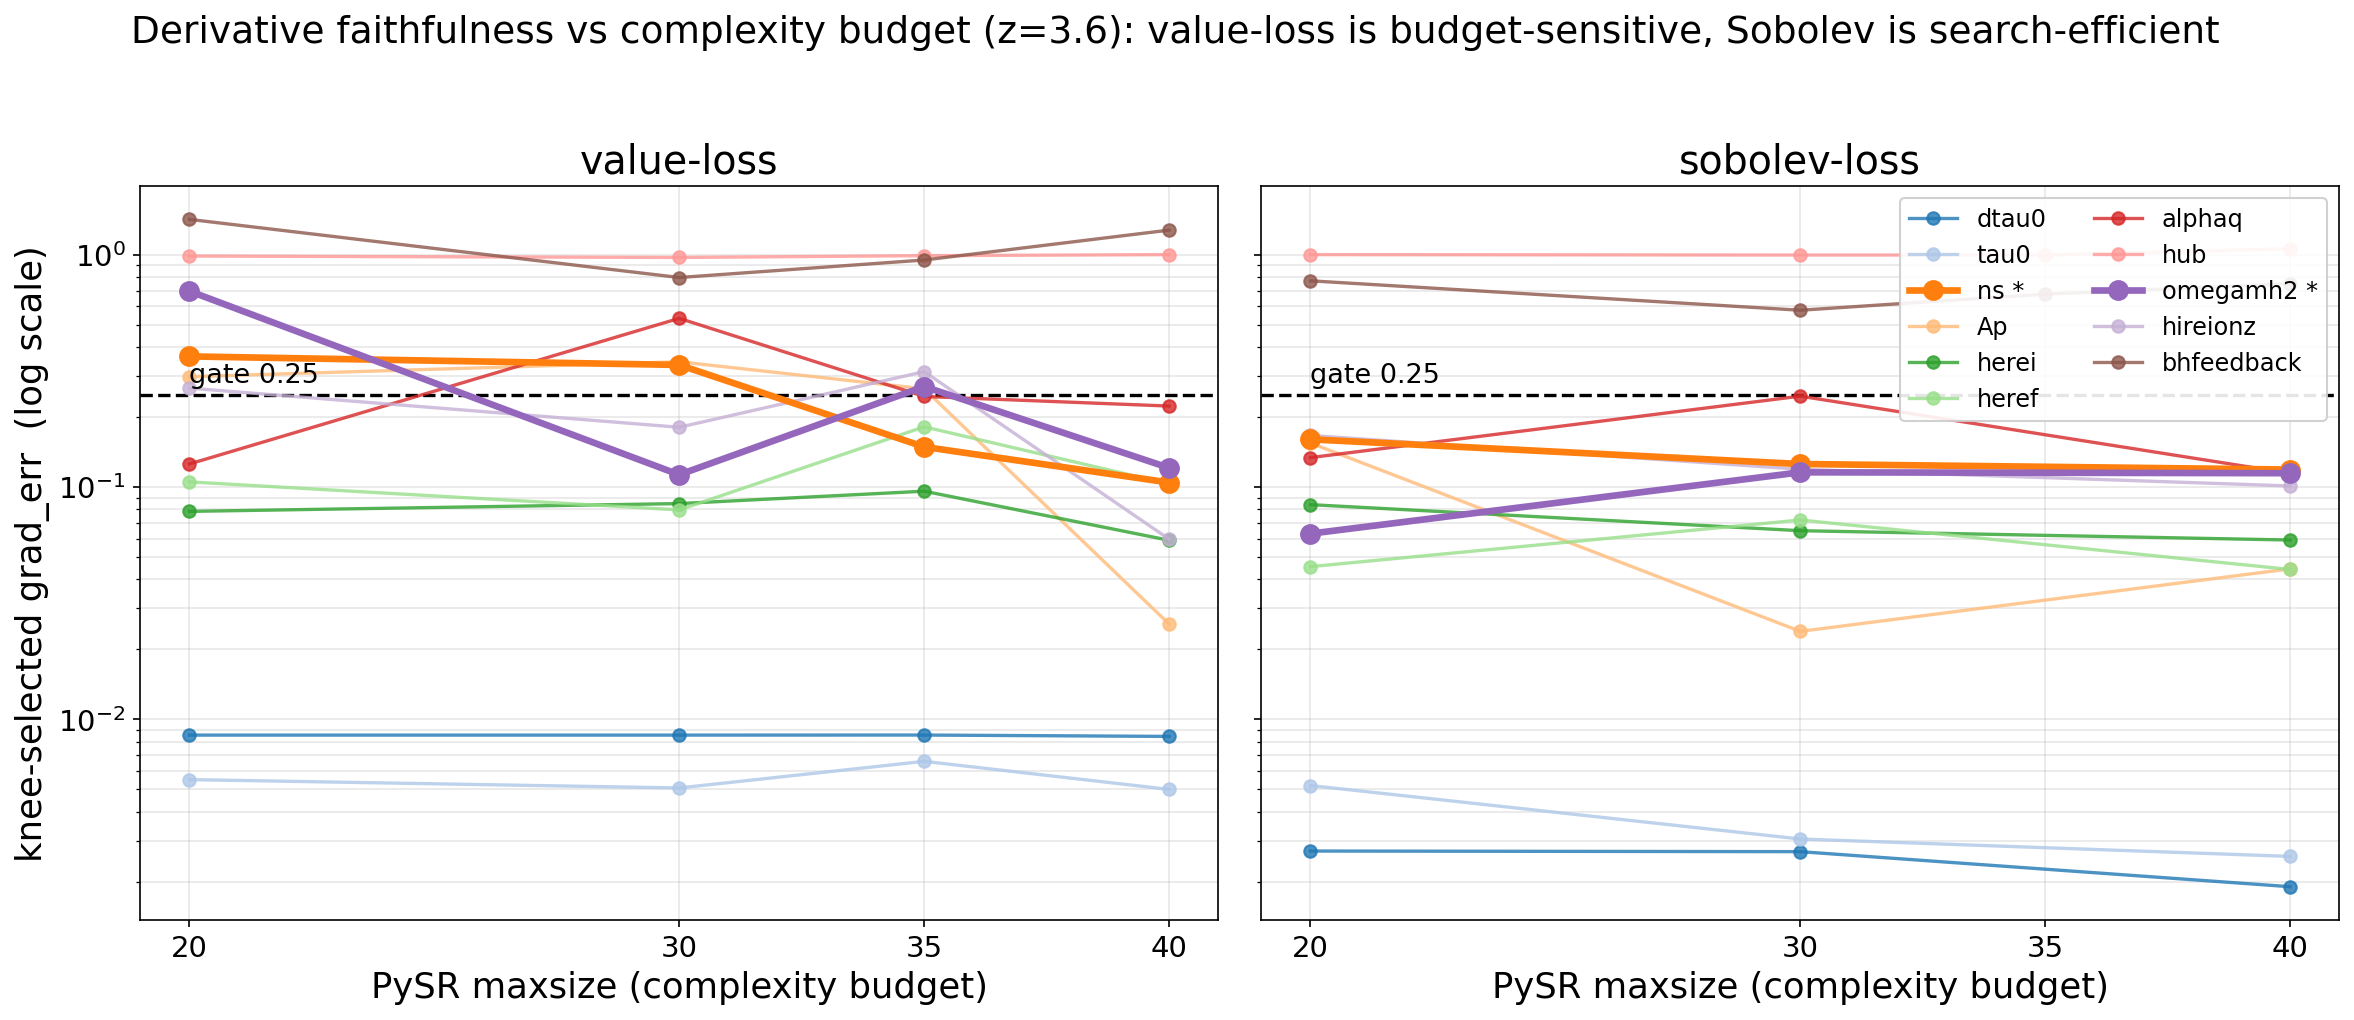

In [5]:
maxsize_out = REPRO / "maxsize"
run_script([
    "scripts/regen_maxsize_sensitivity.py",
    "--prod", PROD, "--z", "3.6", "--out-dir", maxsize_out,
], "regen_maxsize_sensitivity")
display(Image(filename=str(maxsize_out / "maxsize_sensitivity.png")))

## 1.3 `seed_band` — across-seed robustness (from the committed JSON)

There is no standalone plotter for this one — the figure is a few lines of
matplotlib over the committed `seed_band/seed_band_summary.json`, which aggregates
the 5-seed (0–4) run at z=3.6. For each parameter the JSON stores
`[median, min, max, n]` of the **best-loss** `grad_err` for the value and Sobolev
objectives. We plot median markers with [min,max] error bars and the 0.25 gate —
derivative faithfulness is **seed-dependent right at the gate** (ns, Ap, alphaq),
which is exactly why the paper reports a band, not a point.

wrote results/_repro_scratch/reproduced_figures/seed_band.png


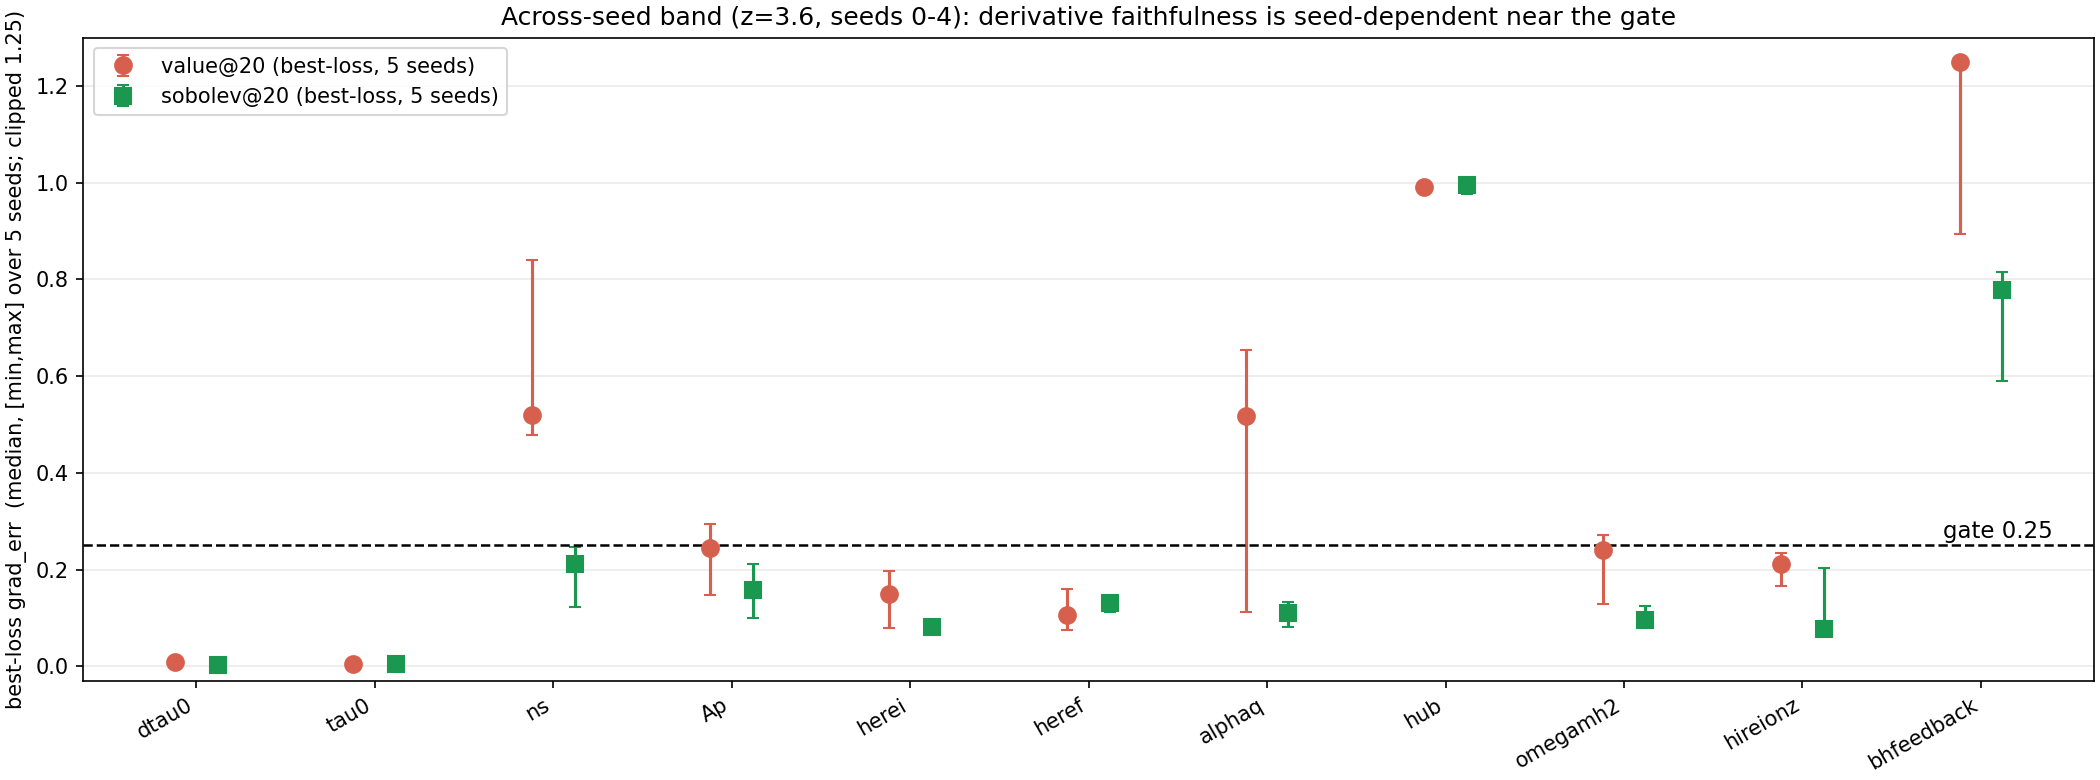

In [6]:
summary = json.loads((PROD / "seed_band" / "seed_band_summary.json").read_text())
gate = summary["gate"]
params = [p for p in PARAM_NAMES if p in summary["params"]]
CLIP = 1.25

def band(p, key):                       # -> (median, lo_err, hi_err), clipped
    med, lo, hi, _ = summary["params"][p][key]
    med = min(med, CLIP)
    return med, med - min(lo, CLIP), min(hi, CLIP) - med

x = np.arange(len(params))
fig, ax = plt.subplots(figsize=(14, 5.2), layout="constrained")
for xi, p in zip(x, params):
    vm, vlo, vhi = band(p, "value")
    sm, slo, shi = band(p, "sobolev")
    ax.errorbar(xi - 0.12, vm, yerr=[[vlo], [vhi]], fmt="o", ms=8, color="#d6604d",
                capsize=3, label="value@20 (best-loss, 5 seeds)" if xi == 0 else None)
    ax.errorbar(xi + 0.12, sm, yerr=[[slo], [shi]], fmt="s", ms=8, color="#1a9850",
                capsize=3, label="sobolev@20 (best-loss, 5 seeds)" if xi == 0 else None)
ax.axhline(gate, color="k", ls="--", lw=1.2)
ax.text(len(params) - 0.6, gate + 0.015, f"gate {gate}", fontsize=11, ha="right")
ax.set_xticks(x); ax.set_xticklabels(params, rotation=30, ha="right")
ax.set_ylabel(f"best-loss grad_err  (median, [min,max] over 5 seeds; clipped {CLIP})")
ax.set_title(f"Across-seed band (z=3.6, seeds {min(summary['seeds'])}-{max(summary['seeds'])}): "
             "derivative faithfulness is seed-dependent near the gate")
ax.set_ylim(-0.03, CLIP + 0.05); ax.grid(axis="y", alpha=.25); ax.legend(loc="upper left")
seed_png = REPRO / "seed_band.png"
fig.savefig(seed_png, dpi=150); fig.savefig(REPRO / "seed_band.pdf")
plt.close(fig)
print("wrote", seed_png)
display(Image(filename=str(seed_png)))

## 1.4 Headline taxonomy table — the numbers reproduce

The paper's central claim is a per-parameter **taxonomy**: value-loss leaves several
parameters above the 0.25 gate (the Mirage), and Sobolev pulls most of them under —
except the two **resistant** parameters (`hub`, `bhfeedback`), whose P1D response is
too weak/degenerate for the gate to adjudicate. Below we recompute, straight from the
committed sidecars, the **knee-selected** `grad_err` for the value vs Sobolev
objective at z=3.6 (the same knee pick the figures use). Compare against the committed
`figures/taxonomy_table.txt` (which tabulates the best-loss pick).

In [7]:
V = PROD / "value/refit/z3.6"
S = PROD / "sobolev/refit/z3.6"

def knee_grad(d, p, col="grad_err"):
    return float(knee_row(read_grad_faith_sidecar(f"{d}/grad_faith_{p}.csv"))[col])

print(f"{'param':11s} {'value_knee':>10s} {'sobolev_knee':>12s}   class")
print("-" * 48)
for p in PARAM_NAMES:
    v, s = knee_grad(V, p), knee_grad(S, p)
    cls = "RESISTANT (> gate under Sobolev)" if s > GATE_TOL else "faithful (Sobolev clears gate)"
    print(f"{p:11s} {v:10.4f} {s:12.4f}   {cls}")

print("\n--- committed figures/taxonomy_table.txt (best-loss pick, for cross-check) ---")
print((PROD / "figures" / "taxonomy_table.txt").read_text())

param       value_knee sobolev_knee   class
------------------------------------------------
dtau0           0.0086       0.0027   faithful (Sobolev clears gate)
tau0            0.0055       0.0052   faithful (Sobolev clears gate)
ns              0.3647       0.1603   faithful (Sobolev clears gate)
Ap              0.2982       0.1546   faithful (Sobolev clears gate)
herei           0.0785       0.0839   faithful (Sobolev clears gate)
heref           0.1051       0.0454   faithful (Sobolev clears gate)
alphaq          0.1256       0.1338   faithful (Sobolev clears gate)
hub             0.9859       1.0000   RESISTANT (> gate under Sobolev)
omegamh2        0.6967       0.0630   faithful (Sobolev clears gate)
hireionz        0.2664       0.1667   faithful (Sobolev clears gate)
bhfeedback      1.4182       0.7714   RESISTANT (> gate under Sobolev)

--- committed figures/taxonomy_table.txt (best-loss pick, for cross-check) ---
Per-parameter derivative-faithfulness taxonomy (z=3.6, gate=0.25

## 1.5 Per-parameter equation table (Table 7, `tab:per1d_eqs`) — reproduced inline

The appendix equation table lists each parameter's production PySR equation at the
**Pareto knee** (lowest complexity within 10% of the front's best loss) under the
Sobolev objective at z=3.6, with its knee complexity, normalized log-$P$ training
loss, and derivative-faithfulness `grad_err`. All of it comes straight from the
committed `sobolev/refit/z3.6/{grad_faith,pareto}_<p>.csv` — **emulator-free**.

In [ ]:
# --- Table 7 (tab:per1d_eqs): per-parameter equations at the Pareto knee ---
# Sobolev objective, z=3.6. For each parameter, knee_row() picks the lowest-
# complexity candidate within 10% of the front's best loss from the grad-faith
# sidecar (giving its complexity, normalized log-P training loss, and grad_err);
# the equation string is then looked up at that complexity in the committed
# Pareto CSV. Fully emulator-free.
S7 = PROD / "sobolev/refit/z3.6"
print(f"{'param':11s}{'cmplx':>6s}{'loss':>11s}{'grad_err':>10s}  equation (x0=theta, x1=k, x2=r)")
print("-" * 98)
for p in PARAM_NAMES:
    kr = knee_row(read_grad_faith_sidecar(f"{S7}/grad_faith_{p}.csv"))
    cx = int(kr["Complexity"])
    par = pd.read_csv(f"{S7}/pareto_{p}.csv")
    eq = str(par.loc[par["Complexity"] == cx, "Equation"].iloc[0])
    print(f"{p:11s}{cx:6d}{float(kr['Loss']):11.4g}{float(kr['grad_err']):10.3f}  {eq[:56]}")
print("\nCross-check vs paper Table 7: ns knee -> cmplx 18, loss 9.75, grad_err 0.160.")

## 1.6 Parameter table (Table 1, `tab:param_table`) — reproduced inline

The 11 varied parameters, their fiducials, and priors are the code's single
source of truth in `priya_forecast.parameters` (mirrored in the committed
`figures/param_priors_table.txt`). Emulator-free — no data files touched.

In [ ]:
# --- Table 1 (tab:param_table): the 11 PRIYA parameters + priors ---
# Straight from priya_forecast.parameters -- the code's single source of truth,
# identical to the committed figures/param_priors_table.txt. No emulator, no
# data files. (Ap is stored internally as A_P / 1e-9, so fid=1.46 => 1.46e-9.)
from priya_forecast.parameters import PARAMS_11D

print(f"{'param':11s}{'latex':18s}{'fid':>10s}{'prior_lo':>10s}{'prior_hi':>10s}")
print("-" * 59)
for p in PARAMS_11D:
    print(f"{p.name:11s}{p.latex:18s}{p.fid:10g}{p.prior[0]:10g}{p.prior[1]:10g}")

print("\n--- committed figures/param_priors_table.txt (cross-check) ---")
print((PROD / "figures" / "param_priors_table.txt").read_text())

---
# Tier 2 — prediction + multi-D figures (require the GP emulator)

> **These cells are NOT executed here.** They need the multi-fidelity GP emulator
> and the project `.venv`. Julia/PySR are **not** needed (the equations are already
> refit and pickled). Run the commands below **after** installing the emulator.

## Environment (set once, in a shell)

```bash
cd /home/mfho/lya1d_priya_forecast
export PYTHON_JULIAPKG_PROJECT=$HOME/.julia_env
export JULIA_DEPOT_PATH=$HOME/.julia
export PYTHONPATH=src:/home/mfho/student_projects/lya_emulator_full
PY=.venv/bin/python                       # the project venv (GPy + lyaemu installed)
PROD=results/paper_production_20260630_perz_sobolev_z2.6-4.2
```

The prediction figures read the **per-z Sobolev refit artifacts** the production run
saved with `--save-artifacts`: `refits/<p>.pkl` + `payloads/<p>.pkl`, committed at
`$PROD/sobolev/refit/z3.6/`.

## Commands

```bash
# --- Fig: pysr_pred_tau0_Ap  (tau0 & Ap 1D variation, LF/HF value + ratio) ---
# regen_fig1.py has NO --refit-dir flag: it hard-codes results/refit_phase2_production.
# Point it at the production artifacts with a symlink, then run:
ln -sfn "$PWD/$PROD/sobolev/refit/z3.6" results/refit_phase2_production
$PY /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite/scripts/regen_fig1.py

# --- Fig: pysr_graphs_3.6_dtau0  (predicted-vs-true P1D, single param) ---
# NOTE: --refit-dir must be the z-dir that holds payloads/ + refits/, i.e.
#       $PROD/sobolev/refit/z3.6  (NOT $PROD/sobolev — the script header example
#       is for a dir laid out payloads/,refits/ directly).
$PY /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite/scripts/regen_fig3.py \
    --param dtau0 --z 3.6 --refit-dir $PROD/sobolev/refit/z3.6 --out-dir $PROD/figures

# --- Fig: 2d-denorm-Sobol_dtau0-Ap  (de-normalized true-vs-pred scatter) ---
$PY /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite/scripts/regen_fig4.py \
    --params dtau0 Ap --z 3.6 --refit-dir $PROD/sobolev/refit/z3.6 \
    --basedir data/kodiaq_gp --out-dir $PROD/figures

# --- multi-D best/worst  (Table-3 backing CSV + figure) ---
# regen_multid takes the PARENT sobolev dir and appends refit/z<z> itself:
$PY scripts/regen_multid.py \
    --refit-dir $PROD/sobolev --z 3.6 --basedir data/kodiaq_gp \
    --out-dir $PROD/figures/multid_z3.6 --n-sobol 256
```

The committed outputs to check against: `$PROD/figures/pysr_pred_tau0_Ap.pdf`,
`$PROD/figures/pysr_graphs_3.6_dtau0.pdf`, `$PROD/figures/2d-denorm-Sobol_dtau0-Ap.pdf`,
and `$PROD/figures/multid_z3.6/multid_bestworst.csv`.

### Verify the committed Tier-2 artifacts exist (emulator-free check)

This cell only checks the committed PDFs/CSV are present — it does **not** run the
emulator. A student who installs the emulator can then re-run the Tier-2 commands
above and diff their output against these.

In [8]:
tier2 = [
    "figures/pysr_pred_tau0_Ap.pdf",
    "figures/pysr_graphs_3.6_dtau0.pdf",
    "figures/2d-denorm-Sobol_dtau0-Ap.pdf",
    "figures/multid_z3.6/multid_bestworst.csv",
]
for rel in tier2:
    f = PROD / rel
    print(f"{'OK  ' if f.exists() else 'MISS'} {rel}  ({f.stat().st_size if f.exists() else 0} bytes)")

# Peek at the committed multi-D table (Tier-2 output, committed so Tier-1 can show it).
print("\n--- committed multi-D best/worst (figures/multid_z3.6/multid_bestworst.csv) ---")
print(pd.read_csv(PROD / "figures/multid_z3.6/multid_bestworst.csv").to_string(index=False))

OK   figures/pysr_pred_tau0_Ap.pdf  (24650 bytes)
OK   figures/pysr_graphs_3.6_dtau0.pdf  (24214 bytes)
OK   figures/2d-denorm-Sobol_dtau0-Ap.pdf  (166213 bytes)
OK   figures/multid_z3.6/multid_bestworst.csv  (551 bytes)

--- committed multi-D best/worst (figures/multid_z3.6/multid_bestworst.csv) ---
dim             params  n_varied  mean_pct  p90_pct  max_pct   max_k  gp_sliced  role
 2D           dtau0-Ap         2    0.7338   1.6954   2.8428 0.00351        NaN   NaN
 2D       herei-alphaq         2    0.6755   1.6036   8.7006 0.00100        NaN   NaN
 2D              Ap-ns         2    0.8766   1.9553   4.8282 0.00100        NaN worst
 2D            tau0-ns         2    0.3427   0.8186   2.9444 0.00100        NaN  best
 2D        herei-heref         2    0.3857   0.9570   4.4669 0.00219        NaN   NaN
 2D            tau0-Ap         2    0.6014   1.4913   3.4500 0.00351        NaN   NaN
 3D        dtau0-Ap-ns         3    0.8634   1.9272   4.8811 0.00100        NaN   NaN
 3D herei-

---
## Done — Tier-1 figures reproduced from the committed artifacts

Final check: assert every Tier-1 PNG was produced.

In [9]:
produced = {
    "pareto_faithfulness":   REPRO / "diagnostic/pareto_faithfulness.png",
    "faithfulness_scorecard":REPRO / "diagnostic/faithfulness_scorecard.png",
    "ns_budget_panel":       REPRO / "diagnostic/ns_budget_panel.png",
    "crossz_faithfulness":   REPRO / "diagnostic/crossz_faithfulness.png",
    "maxsize_sensitivity":   REPRO / "maxsize/maxsize_sensitivity.png",
    "seed_band":             REPRO / "seed_band.png",
}
ok = True
for name, f in produced.items():
    present = f.exists() and f.stat().st_size > 0
    ok = ok and present
    print(f"{'OK  ' if present else 'MISS'} {name:24s} {f}")
assert ok, "a Tier-1 figure is missing"
print("\nAll 6 Tier-1 figures reproduced EMULATOR-FREE from the committed production artifacts.")

OK   pareto_faithfulness      results/_repro_scratch/reproduced_figures/diagnostic/pareto_faithfulness.png
OK   faithfulness_scorecard   results/_repro_scratch/reproduced_figures/diagnostic/faithfulness_scorecard.png
OK   ns_budget_panel          results/_repro_scratch/reproduced_figures/diagnostic/ns_budget_panel.png
OK   crossz_faithfulness      results/_repro_scratch/reproduced_figures/diagnostic/crossz_faithfulness.png
OK   maxsize_sensitivity      results/_repro_scratch/reproduced_figures/maxsize/maxsize_sensitivity.png
OK   seed_band                results/_repro_scratch/reproduced_figures/seed_band.png

All 6 Tier-1 figures reproduced EMULATOR-FREE from the committed production artifacts.
